# Bond Greeks, curve risk and hedging

See what duration removes, what convexity adds and what a one-swap hedge leaves.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

“DV01” is incomplete without the variable that moves. A parallel yield bump, a continuous zero spread and a parallel shift to bootstrapped market quotes can produce different sensitivities because they change different objects.

The connected study defines signed quote DV01 as $[P(q+1bp)-P(q-1bp)]/2$, in currency per positive basis point. It rebuilds discount and projection curves for each bump. Bond DV01 is negative with this convention. Separate quote buckets reveal the term-structure directions hidden in one parallel number.

The notebook independently differentiates discounted bond cash flows with respect to a continuous zero spread: $-10^{-4}\sum_i t_iCF_iD_i$. A central difference checks that derivative. It then reads the primary study's frozen hedge and scenario revaluations, verifying $\Delta P_{hedged}=\Delta P_{bond}+h\Delta P_{swap}$. The companion figure compares exact residuals with a bucket approximation across parallel, slope and local-tenor shocks.

The hedge ratio $h=-DV01_{bond}/DV01_{swap}$ removes one first-order direction at inception. It does not cancel every tenor bucket, the separate projection exposure, or all second-order effects. All shocks are instantaneous, with coupon and positions frozen. Carry, roll-down, trade costs and rebalancing are outside this experiment.

[The full study](../../study.ipynb) retains the calibrated inputs, bump-size checks and convention alternatives needed to interpret these residuals.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
flows=pd.read_csv(RESULTS/'cashflows.csv').query('instrument=="bond"').copy()
t=np.array([ql.Actual365Fixed().yearFraction(DATE,ql.DateParser.parseISO(x)) for x in flows.date])
analytic=-1e-4*np.sum(t*flows.pv)
h=.000001
central=np.sum(flows.pv*(np.exp(-h*t)-np.exp(h*t)))/(2*h)*1e-4
assert abs(analytic-central)<1e-8
pnl=pd.read_csv(RESULTS/'scenario_pnl.csv')
hedge=pd.read_csv(RESULTS/'hedge.csv').iloc[0].swap_units
assert np.allclose(pnl.hedged_pnl,pnl.unhedged_bond_pnl+hedge*pnl.swap_pnl_per100,atol=1e-12)
display(pd.DataFrame([{'zero_spread_analytic_DV01':analytic,'zero_spread_central_DV01':central,'swap_units_per_100_bond':hedge}]))
display(pnl.round(6))

,zero_spread_analytic_DV01,zero_spread_central_DV01,swap_units_per_100_bond
0,-0.063951,-0.063951,1.009745


,scenario,unhedged_bond_pnl,swap_pnl_per100,hedged_pnl,bucket_first_order,parallel_second_order
0,parallel_up100,-6.017852,5.958459,-0.001330,-0.000000,-0.001389
1,parallel_down100,6.487715,-6.426543,-0.001452,0.000000,-0.001389
2,steepener,-1.016854,1.037500,0.030756,0.030682,NaN
3,flattener,1.013092,-1.033628,-0.030608,-0.030682,NaN
4,local_7y,-6.097930,6.109656,0.071261,0.072413,NaN


## Economic relationship

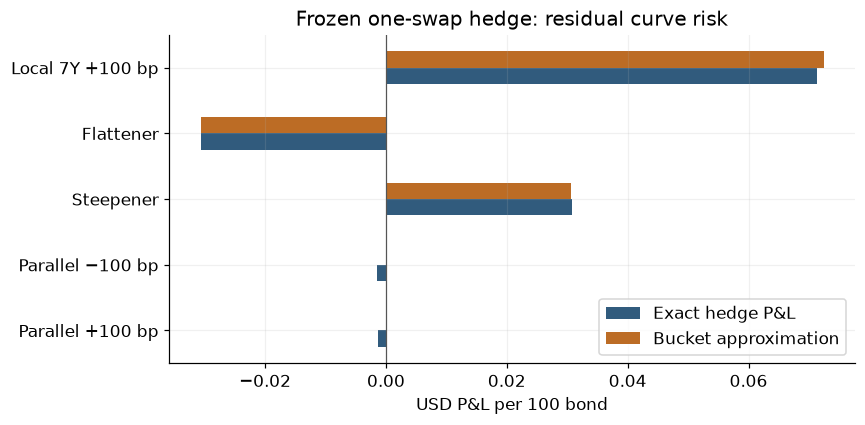

In [3]:
fig,ax=plt.subplots(figsize=(8,4))
pnl.set_index('scenario')[['hedged_pnl','bucket_first_order']].rename(columns={'hedged_pnl':'Exact hedge P&L','bucket_first_order':'Bucket approximation'}, index={'local_7y':'Local 7Y +100 bp','flattener':'Flattener','steepener':'Steepener','parallel_down100':'Parallel −100 bp','parallel_up100':'Parallel +100 bp'}).plot.barh(ax=ax,color=['#315b7d','#bc6c25'])
ax.axvline(0,color='#555555',lw=.8)
ax.set(xlabel='USD P&L per 100 bond',ylabel='',title='Frozen one-swap hedge: residual curve risk')
fig.tight_layout();plt.show()

## Interpretation

The independent zero-spread derivative agrees with its finite difference. The frozen swap removes most parallel sensitivity, while the local 7Y and slope shocks expose residual curve risk. Zero-spread DV01 and quote DV01 remain different measures.